In [1]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr, kendalltau, permutation_test
import matplotlib.pyplot as plt
import numpy as np

In [2]:
metric_results_kwtest = pd.read_csv('./keyWordLdaMataveTest/ldaMataveMetrics.csv')
metric_results_localraw = pd.read_csv('./rawLocalImplementation/localOnlineImplementation.csv')
human_results_kwtest = pd.read_csv('./keyWordLdaMataveTest/dataGeneration/experimentTestNoteShuffle/sent/humanResults.csv')
# Taken from LangChain paper (reported results): https://doi.org/10.1016/j.jbi.2025.104936
human_results_localraw = pd.DataFrame({
    "model": ['gpt3Notes', 'gpt4Notes'],
    "F1 Score": [0.8378, 0.6898] ,
    "Cohen's Kappa": [0.6331, 0.2674]
})

In [3]:
metric_results_kwtest

,model,CHI,ZIPF,CLASSIFIER,IRPR,FID,PR,DC,MAUVE,TRADITIONAL,ZERO
0,allTopicModels,0.000000,0.184044,0.967033,0.314002,0.759336,0.698251,0.932879,0.970704,0.510824,0.246050
1,LDA,0.000000,0.172124,0.951994,0.306521,0.726224,0.645994,0.915669,0.973749,0.504291,0.262112
2,MATAVE,0.000000,0.197774,0.983740,0.333860,0.837725,0.716517,0.941933,0.984797,0.518210,0.203755
3,realToReal,0.667949,0.027829,0.452498,0.193086,0.241809,0.117652,0.067015,0.030778,0.191097,0.091320
4,realToReal2,1.000000,0.047323,0.424715,0.189089,0.235171,0.112295,0.060020,0.015929,0.164203,0.113025
5,realToReal3,1.000000,0.012167,0.484539,0.190729,0.244031,0.127213,0.005042,0.021362,0.167957,0.098905


In [4]:
# make individual metric datasets 
individual_metrics_kwtest = pd.read_csv('./keyWordLdaMataveTest/outputScores/evaluated_scaled_results.csv')
individual_metrics_localraw = pd.read_csv('./rawLocalImplementation/outputScores/evaluated_scaled_results.csv')
all_individual_metrics = pd.concat([individual_metrics_kwtest, individual_metrics_localraw])
all_notes = all_individual_metrics.groupby('generation_type')['number_of_notes'].sum().reset_index()
all_individual_metrics = all_individual_metrics.drop(columns=['topic_model', 'dataset', 'needs', 'prompt_id', 'number_of_notes', 'sentiment', 'subjectivity'])
all_individual_metrics = all_individual_metrics.groupby('generation_type').mean().reset_index()

all_individual_metrics['model'] = [name.replace('fakeOnlineGPT3', 'gpt3Notes').replace('fakeOnlineGPT4', 'gpt4Notes') for name in all_individual_metrics['generation_type']]
all_individual_metrics['Original Metric Mean'] = all_individual_metrics['overall_score']
all_individual_metrics.drop(columns=['generation_type', 'overall_score'], inplace=True)
all_individual_metrics = all_individual_metrics[all_individual_metrics['model'] != 'fakeLocal']

In [5]:
all_notes

,generation_type,number_of_notes
0,LDA,2396
1,MATAVE,2313
2,allTopicModels,9418
3,fakeLocal,2385
4,fakeOnlineGPT3,5783
5,fakeOnlineGPT4,6253


In [6]:
metric_results_localraw = metric_results_localraw[(metric_results_localraw['dataset'] != 'realToReal') & (metric_results_localraw['dataset'] != 'realToReal_2') & (metric_results_localraw['dataset'] != 'realToReal_3')]
metric_results_localraw['model'] = metric_results_localraw['dataset']
metric_results_localraw = metric_results_localraw.drop(columns='dataset')
all_metric_comparisons = pd.concat([metric_results_kwtest, metric_results_localraw])
all_metric_comparisons = all_metric_comparisons[all_metric_comparisons['model'] != 'processedFakeNoteSyntheticNotes']

human_results_kwtest = human_results_kwtest.drop(columns=['Accuracy', 'Precision', 'Recall'])
all_human_comparisons = pd.concat([human_results_kwtest, human_results_localraw])

In [7]:
# Get metric columns. 
metric_cols = [c for c in all_metric_comparisons.columns if 'model' not in c]
# Extract real rows.
real_mask = all_metric_comparisons['model'].str.startswith('real')
real_df = all_metric_comparisons.loc[real_mask, metric_cols]

In [8]:
# Get mean and standard deviation. 
mean = real_df.mean()
std_dev = real_df.std(ddof=1)
# There should be a minimum standard deviation, otherwise the metric is returning all 0s or exhibits no variation (which we assume is not indicative of a perfect metric, but a failing one).
min_std = 1e-4

# Reliability is inverse standard deviation. 
reliability = pd.Series(index=std_dev.index, dtype=float)

for metric in std_dev.index:
    # Real-vs-real values for this metric
    real_values = real_df[metric]

    # Detect saturation at minimum or maximum
    all_zero = np.allclose(real_values, 0, atol=0.01)
    all_one = np.allclose(real_values, 1, atol=0.01)

    if all_zero or all_one:
        reliability[metric] = 0

    elif std_dev[metric] < min_std:
        reliability[metric] = 0

    else:
        reliability[metric] = 1

if reliability.sum() == 0:
    raise ValueError(
        "All metrics were assigned zero reliability."
    )

# Safe standard deviation for z-scoring.
safe_std = std_dev.copy()
safe_std[safe_std < min_std] = min_std

# Calibrate scores.
calibrated = all_metric_comparisons.copy()

for m in metric_cols:
    calibrated[m] = (
        (all_metric_comparisons[m] - mean[m])
        / safe_std[m]
    )

weights = reliability / reliability.sum()

calibrated["Framework Score"] = (
    calibrated[metric_cols] * weights
).sum(axis=1)

In [9]:
merged = all_human_comparisons.merge(calibrated, on="model", how="inner")


In [10]:
weights

CHI            0.1
ZIPF           0.1
CLASSIFIER     0.1
IRPR           0.1
FID            0.1
PR             0.1
DC             0.1
MAUVE          0.1
TRADITIONAL    0.1
ZERO           0.1
dtype: float64

In [11]:
weight_rank = weights.rank(ascending=False, method="dense").astype(int)
weight_rank

CHI            1
ZIPF           1
CLASSIFIER     1
IRPR           1
FID            1
PR             1
DC             1
MAUVE          1
TRADITIONAL    1
ZERO           1
dtype: int64

In [12]:
merged

,Unnamed: 0,model,F1 Score,Cohen's Kappa,CHI,ZIPF,CLASSIFIER,IRPR,FID,PR,DC,MAUVE,TRADITIONAL,ZERO,Framework Score
0,MATAVE,MATAVE,0.800000,0.631766,-6.286889,9.569642,17.694078,87.361670,131.687441,79.434328,28.632964,158.822977,30.599003,10.459090,54.797430
1,LDA,LDA,0.929461,0.854037,-6.286889,8.112110,16.633311,70.696104,107.120363,70.053744,27.799695,157.002301,29.372070,16.519154,49.702196
2,allTopicModels,allTopicModels,0.869955,0.745196,-6.286889,8.789450,17.135832,75.256448,114.415925,77.004677,28.345725,156.500486,29.947895,14.851230,51.596078
3,NaN,gpt3Notes,0.837800,0.633100,-6.286889,6.083104,16.588520,82.889276,129.740238,83.992357,28.865475,155.473506,29.034393,15.329784,54.170976
4,NaN,gpt4Notes,0.689800,0.267400,-6.286889,8.246346,17.435354,94.359359,148.957310,86.740875,29.225220,159.073104,30.865740,18.268782,58.688520


In [13]:
merged = merged.merge(all_individual_metrics, on='model', how="inner")

In [14]:
merged = merged.rename(columns={
    "final_score": "Framework Score",
    "bertscore": "BERTScore",
    "meteor": "METEOR",
    "abs_sentiment_diff": "Abs Sentiment Diff",
    "abs_subjectivity_diff": "Abs Subjectivity Diff",
    "original_metric_mean": "Original Metric Mean",
})

merged[['model', 'F1 Score', "Cohen's Kappa", 'Framework Score', 'Original Metric Mean']]

,model,F1 Score,Cohen's Kappa,Framework Score,Original Metric Mean
0,MATAVE,0.800000,0.631766,54.797430,0.520031
1,LDA,0.929461,0.854037,49.702196,0.572163
2,allTopicModels,0.869955,0.745196,51.596078,0.543216
3,gpt3Notes,0.837800,0.633100,54.170976,0.546350
4,gpt4Notes,0.689800,0.267400,58.688520,0.537258


/var/folders/12/p5c0vdcj3yx9xb69fcd0n3j80000gn/T/ipykernel_9235/2315256245.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  p_corr, pp_value = pearsonr(
/var/folders/12/p5c0vdcj3yx9xb69fcd0n3j80000gn/T/ipykernel_9235/2315256245.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  s_corr, sp_value = spearmanr(


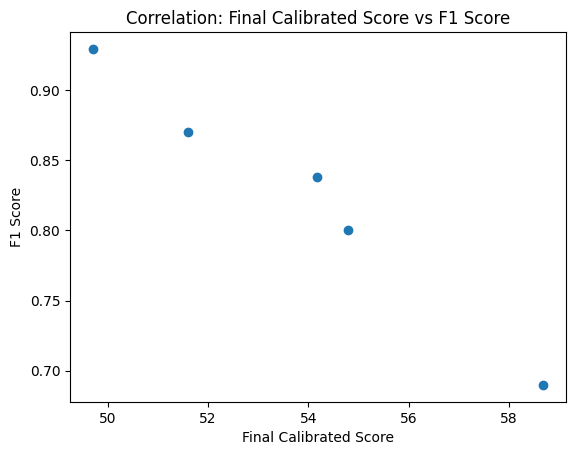

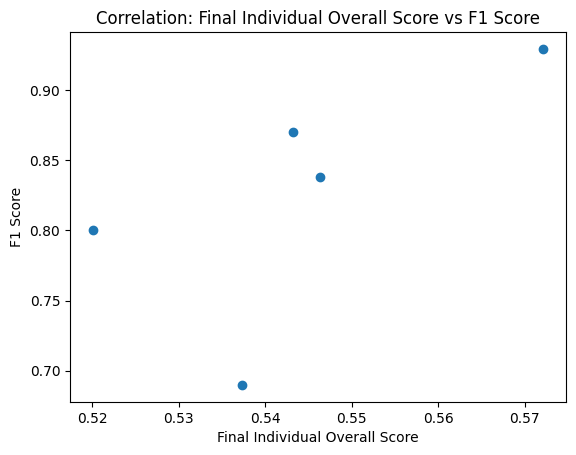

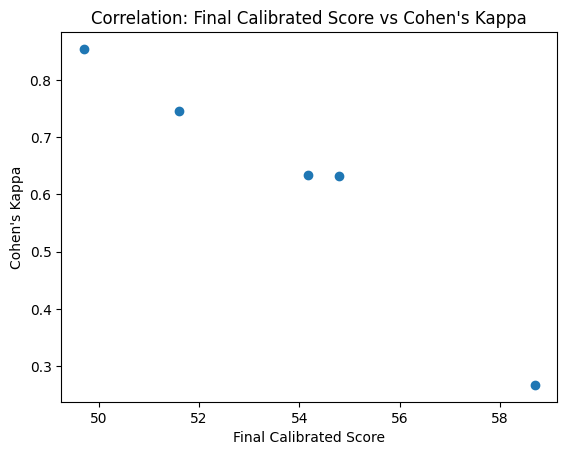

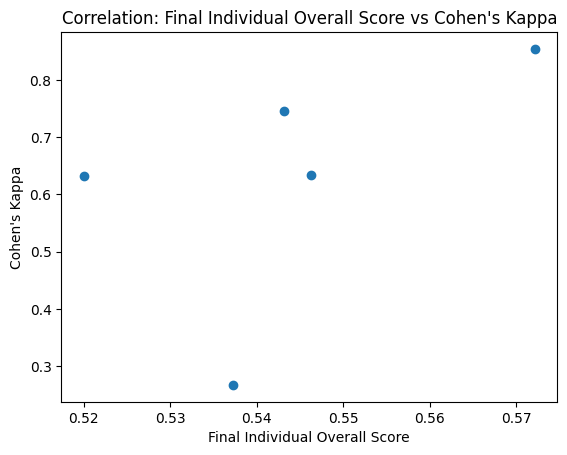

In [15]:
all_results_for_df = []
for comparison in ["F1 Score", "Cohen's Kappa"]:
    for metric in ["CHI", "ZIPF", "CLASSIFIER", "IRPR", "FID", "PR", "DC", "MAUVE", "TRADITIONAL", "ZERO", "Framework Score", "BERTScore", "METEOR", "Abs Sentiment Diff", "Abs Subjectivity Diff", "Original Metric Mean"]:
        # Pearson is standardized and works best for linear relationships. 
        p_corr, pp_value = pearsonr(
            merged[metric],
            merged[comparison]
        )

        # Spearman's does not need linearity, robust to outliers, no distributional assumptions (non normal distribution), versatile in variable types. 
        s_corr, sp_value = spearmanr(
            merged[metric],
            merged[comparison]
        )

        # Kendall's Tau as there is a very small sample size. 
        tau, kp_value = kendalltau(
            merged[metric],
            merged[comparison]
        )


        all_results_for_df.append({
        'metric': metric,
        'comparison': comparison,
        'pearson': p_corr,
        'pearson p-value': pp_value,
        'spearman': s_corr,
        'spearman p-value': sp_value,
        'kendall': tau, 
        'kendall p-value': kp_value,
        })

    plt.scatter(
    merged["Framework Score"],
    merged[comparison]
    )

    plt.xlabel("Final Calibrated Score")
    plt.ylabel(comparison)
    plt.title(f"Correlation: Final Calibrated Score vs {comparison}")
    plt.show()

    plt.scatter(
    merged["Original Metric Mean"],
    merged[comparison]
    )

    plt.xlabel("Final Individual Overall Score")
    plt.ylabel(comparison)
    plt.title(f"Correlation: Final Individual Overall Score vs {comparison}")
    plt.show()

In [16]:
statistical_tests = pd.DataFrame(all_results_for_df)
statistical_tests[statistical_tests['metric'] == 'Framework Score']


,metric,comparison,pearson,pearson p-value,spearman,spearman p-value,kendall,kendall p-value
10,Framework Score,F1 Score,-0.988587,0.001461,-1.0,1.404265e-24,-1.0,0.016667
26,Framework Score,Cohen's Kappa,-0.975346,0.004630,-1.0,1.404265e-24,-1.0,0.016667


In [17]:
statistical_tests[statistical_tests['metric'] == 'Original Metric Mean']

,metric,comparison,pearson,pearson p-value,spearman,spearman p-value,kendall,kendall p-value
15,Original Metric Mean,F1 Score,0.660056,0.225400,0.8,0.104088,0.6,0.233333
31,Original Metric Mean,Cohen's Kappa,0.518658,0.370559,0.8,0.104088,0.6,0.233333


In [18]:
statistical_tests.to_csv('./statisticalTestsEqual.csv')

/var/folders/12/p5c0vdcj3yx9xb69fcd0n3j80000gn/T/ipykernel_9235/1788084684.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda x, y: pearsonr(x, y).statistic,
/var/folders/12/p5c0vdcj3yx9xb69fcd0n3j80000gn/T/ipykernel_9235/1788084684.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda x, y: spearmanr(x, y).statistic,


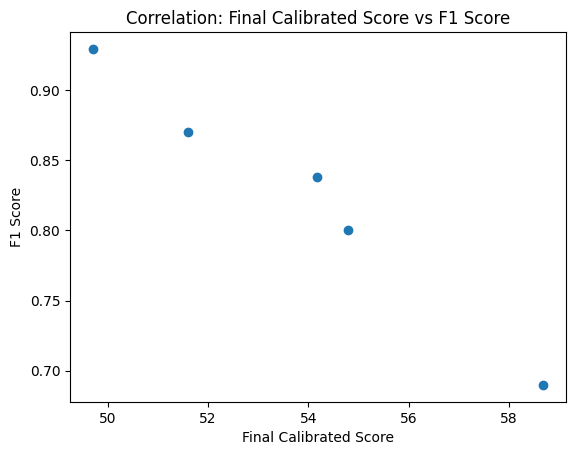

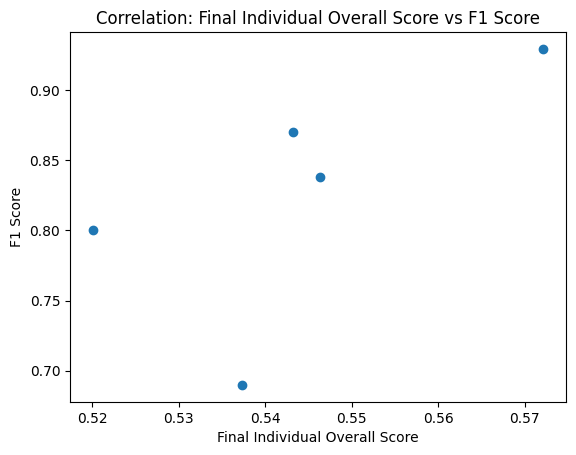

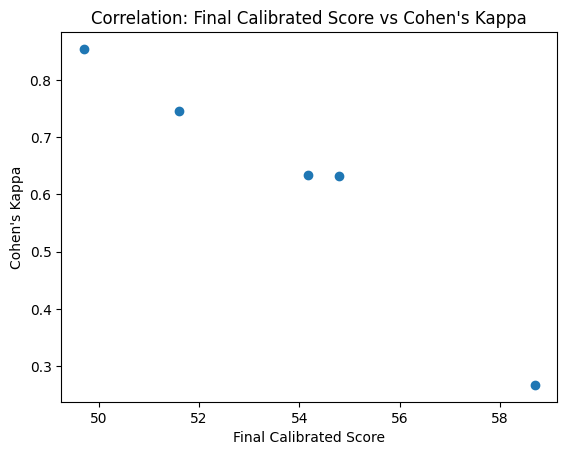

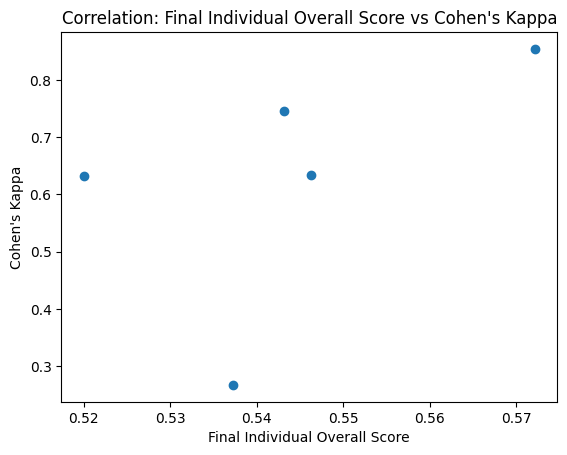

In [19]:
all_results_for_df = []
for comparison in ["F1 Score", "Cohen's Kappa"]:
    for metric in ["CHI", "ZIPF", "CLASSIFIER", "IRPR", "FID", "PR", "DC", "MAUVE", "TRADITIONAL", "ZERO", "Framework Score", "BERTScore", "METEOR", "Abs Sentiment Diff", "Abs Subjectivity Diff", "Original Metric Mean"]:
        x = merged[metric]
        y = merged[comparison]


        # Pearson is standardized and works best for linear relationships. 
        result = permutation_test(
            (x, y),
            lambda x, y: pearsonr(x, y).statistic,
            permutation_type="pairings",
            alternative="two-sided",
            n_resamples=np.inf
        )
        p_corr, pp_value = result.statistic, result.pvalue

        # Spearman's does not need linearity, robust to outliers, no distributional assumptions (non normal distribution), versatile in variable types.
        result = permutation_test(
            (x, y),
            lambda x, y: spearmanr(x, y).statistic,
            permutation_type="pairings",
            alternative="two-sided",
            n_resamples=np.inf
        )
        s_corr, sp_value = result.statistic, result.pvalue

        # Kendall's Tau as there is a very small sample size. 
        result = permutation_test(
            (x, y),
            lambda x, y: kendalltau(x, y).statistic,
            permutation_type="pairings",
            alternative="two-sided",
            n_resamples=np.inf
        )
        tau, kp_value = result.statistic, result.pvalue


        all_results_for_df.append({
        'metric': metric,
        'comparison': comparison,
        'pearson': p_corr,
        'pearson p-value': pp_value,
        'spearman': s_corr,
        'spearman p-value': sp_value,
        'kendall': tau, 
        'kendall p-value': kp_value,
        })

    plt.scatter(
    merged["Framework Score"],
    merged[comparison]
    )

    plt.xlabel("Final Calibrated Score")
    plt.ylabel(comparison)
    plt.title(f"Correlation: Final Calibrated Score vs {comparison}")
    plt.show()

    plt.scatter(
    merged["Original Metric Mean"],
    merged[comparison]
    )

    plt.xlabel("Final Individual Overall Score")
    plt.ylabel(comparison)
    plt.title(f"Correlation: Final Individual Overall Score vs {comparison}")
    plt.show()

In [20]:
statistical_tests = pd.DataFrame(all_results_for_df)
statistical_tests[statistical_tests['metric'] == 'Framework Score']


,metric,comparison,pearson,pearson p-value,spearman,spearman p-value,kendall,kendall p-value
10,Framework Score,F1 Score,-0.988587,0.016667,-1.0,0.016667,-1.0,0.016667
26,Framework Score,Cohen's Kappa,-0.975346,0.016667,-1.0,0.016667,-1.0,0.016667


In [21]:
statistical_tests[statistical_tests['metric'] == 'Original Metric Mean']

,metric,comparison,pearson,pearson p-value,spearman,spearman p-value,kendall,kendall p-value
15,Original Metric Mean,F1 Score,0.660056,0.183333,0.8,0.133333,0.6,0.233333
31,Original Metric Mean,Cohen's Kappa,0.518658,0.316667,0.8,0.133333,0.6,0.233333


In [22]:
statistical_tests.to_csv('./statisticalTestsEqualPermutations.csv')